# Setup C -- Spiderwheel-Based Effective Sampled Mass Estimate

First-order mechanistic approximation for wheel-driven powder renewal and binary probe blocking during one NIR spectral acquisition.

## Background

Setup C represents a spiderwheel-driven powder presentation geometry for NIR diffuse reflectance measurement. As in the other notebooks in this series, the interaction region is treated as a shallow near-surface region in front of the probe window, and the sampled mass is approximated from probe footprint, assumed penetration depth, and bulk density.

The key physical difference from Setup B is that Setup B treats each spoon presentation as a static measurement event, whereas Setup C uses wheel motion to actively renew powder at the probe location during a single acquisition. The spiderwheel therefore introduces two competing effects: it can increase the rate at which newly presented powder passes through the probe region, but the fingers can also intermittently block the probe and reduce the usable observation time.

This notebook is therefore positioned as a first-order mechanistic approximation and a deterministic renewal model. It is intended to quantify effective sampled mass trends and blocking trends, not to claim a validated statistical effective sample size or a full radiative-transfer description of the measurement.

## Objective

This notebook estimates, for Setup C:

- sampled mass per refresh event
- blocked and unblocked acquisition time during one spectrum
- number of refresh opportunities during one spectrum
- effective sampled mass estimate per spectrum
- sensitivity of the estimate to penetration depth, bulk density, and wheel RPM

## Theory

Wheel kinematics at the probe position:

$$
\omega = \frac{2\pi \, \mathrm{RPM}}{60}
$$

$$
v = \omega \, r_{\mathrm{pos}}
$$

where $r_{\mathrm{pos}}$ is the radial distance from the wheel center to the probe center (not half of the probe diameter).

First-order footprint and sampled mass per refresh event:

$$
A_{\mathrm{probe}} = \pi \left(\frac{D_{\mathrm{probe}}}{2}\right)^2
$$

$$
V_{\mathrm{sample}} = A_{\mathrm{probe}} \, d_{\mathrm{pen}}
$$

$$
m_{\mathrm{sample}} = \rho_{\mathrm{bulk}} \, V_{\mathrm{sample}}
$$

Characteristic renewal time scale:

$$
t_{\mathrm{cross}} = \frac{D_{\mathrm{probe}}}{v}
$$

This is the time required for a powder segment moving at the local tangential speed $v$ to traverse one probe diameter. It represents the characteristic time scale on which the material in front of the probe is replaced by newly arriving material, and therefore sets the renewal rate.

Binary blocking geometry:

Each spiderwheel finger has a tangential width $w_{\mathrm{finger}}$ at the probe's radial position. At a distance $r_{\mathrm{pos}}$ from the wheel center, the finger and the probe each subtend small angles:

$$
\theta_{\mathrm{finger}} = \frac{w_{\mathrm{finger}}}{r_{\mathrm{pos}}}
\qquad\qquad
\theta_{\mathrm{probe}} = \frac{D_{\mathrm{probe}}}{r_{\mathrm{pos}}}
$$

These are chord-over-radius approximations valid when the widths are small compared to $r_{\mathrm{pos}}$.

Blocking begins when the leading edge of a finger reaches the leading edge of the probe and ends when the trailing edge of the finger clears the trailing edge of the probe. The total overlap angle per finger pass is therefore the sum of both angular widths:

$$
\theta_{\mathrm{overlap}} = \theta_{\mathrm{finger}} + \theta_{\mathrm{probe}}
$$

The time blocked by one finger pass at angular speed $\omega$ is:

$$
t_{\mathrm{block,1}} = \frac{\theta_{\mathrm{overlap}}}{\omega}
$$

The number of individual finger passes during one acquisition is estimated from the rotation rate and the number of fingers:

$$
N_{\mathrm{pass}} = \left\lceil \frac{t_{\mathrm{acq}} \cdot \mathrm{RPM} \cdot n_{\mathrm{fingers}}}{60} \right\rceil
$$

Total blocked time is the sum of all individual blocking events, capped at the acquisition time:

$$
t_{\mathrm{blocked}} = \min\!\left(t_{\mathrm{acq}},\; N_{\mathrm{pass}} \cdot t_{\mathrm{block,1}}\right)
$$

Effective unblocked acquisition time:

$$
t_{\mathrm{eff}} = \max\left(0,\; t_{\mathrm{acq}} - t_{\mathrm{blocked}}\right)
$$

Deterministic renewal count:

$$
N_{\mathrm{refresh}} = \frac{t_{\mathrm{eff}}}{t_{\mathrm{cross}}}
$$

Effective sampled mass estimate during one acquisition:

$$
m_{\mathrm{eff,est}} = m_{\mathrm{sample}} \, N_{\mathrm{refresh}}
$$

Symbol definitions and units:

- $\mathrm{RPM}$: wheel rotation rate [rev min$^{-1}$]
- $\omega$: angular speed [rad s$^{-1}$]
- $r_{\mathrm{pos}}$: radial distance from wheel center to probe center [cm]
- $v$: tangential speed at the probe's radial position [cm s$^{-1}$]
- $D_{\mathrm{probe}}$: probe window diameter [cm] in calculations, reported as [mm] in engineering tables and labels
- $A_{\mathrm{probe}}$: probe footprint area [cm$^2$]
- $d_{\mathrm{pen}}$: assumed penetration depth [cm] in calculations, reported as [mm] in engineering tables and labels
- $V_{\mathrm{sample}}$: sampled volume per refresh event [cm$^3$]
- $\rho_{\mathrm{bulk}}$: bulk density [g cm$^{-3}$]
- $m_{\mathrm{sample}}$: sampled mass per refresh event [g]
- $w_{\mathrm{finger}}$: tangential width of one spiderwheel finger at the probe's radial position [cm]
- $n_{\mathrm{fingers}}$: number of spiderwheel fingers [-]
- $\theta_{\mathrm{finger}}$: angular width of one finger at $r_{\mathrm{pos}}$ [rad]
- $\theta_{\mathrm{probe}}$: angular width of the probe window at $r_{\mathrm{pos}}$ [rad]
- $\theta_{\mathrm{overlap}}$: total overlap angle per finger pass [rad]
- $t_{\mathrm{block,1}}$: time blocked by a single finger pass [s]
- $N_{\mathrm{pass}}$: number of finger passes during one acquisition [-]
- $t_{\mathrm{acq}}$: total spectral acquisition time [s]
- $t_{\mathrm{blocked}}$: total time during which the probe is treated as blocked [s]
- $t_{\mathrm{eff}}$: effective unblocked acquisition time [s]
- $t_{\mathrm{cross}}$: characteristic crossing time for one probe diameter of tangential motion [s]
- $N_{\mathrm{refresh}}$: deterministic renewal count during one acquisition [-]
- $m_{\mathrm{eff,est}}$: effective sampled mass estimate during one acquisition [g]

The code uses mixed practical engineering units for convenience: geometry is entered mainly in cm and mm, density in g/cm$^3$, time in s, and reported masses are often shown in mg. The calculations remain internally consistent because the unit conversions are handled explicitly in the code.

## Interpretation of the Model

In this notebook, a *refresh* means the passage of newly presented powder across the probe region due to wheel motion. It is best interpreted as a renewal opportunity for material presented to the probe window, not as proof of a statistically independent new sample.

Tangential speed is evaluated at the probe's radial position on the wheel ($r_{\mathrm{pos}}$) because the local renewal rate should be tied to the wheel speed where the probe actually views the material. The crossing time $t_{\mathrm{cross}}$ is then interpreted as a characteristic time scale for a wheel-driven material segment to traverse one probe width.

Blocked time is subtracted because the model uses a binary blocking approximation: when a spiderwheel finger overlaps the probe region, the probe is treated as having no usable access to powder during that interval. The resulting $t_{\mathrm{eff}}$ is therefore an effective observation time rather than the full instrument acquisition time.

$N_{\mathrm{refresh}}$ should therefore be interpreted as a deterministic renewal count, rather than a demonstrated count of independent samples. Powder recirculation, revisit probability, local residence-time memory, and correlation between successive refresh events are not modeled. For the same reason, $m_{\mathrm{eff,est}}$ is an effective sampled mass estimate, not yet a validated statistical effective sample size and not a direct estimate of analytical variance.

Despite these simplifications, the model is still useful as a mechanistic engineering tool because it shows how geometry, density, penetration depth, RPM, and blocking assumptions influence the amount of powder that is plausibly renewed in front of the probe during one spectrum.

## Assumptions

- circular probe window with area represented by $A_{\mathrm{probe}}$
- first-order cylindrical sampled volume approximation, $V_{\mathrm{sample}} = A_{\mathrm{probe}} d_{\mathrm{pen}}$
- constant bulk density over the sampled region
- constant assumed penetration depth for each simulation condition
- local renewal rate represented by tangential velocity at the probe's radial position on the wheel ($r_{\mathrm{pos}}$)
- binary blocking behavior when a spiderwheel finger overlaps the probe region
- no partial transmission, partial attenuation, or partial exposure through a finger
- no revisit probability or recirculation correction for previously presented powder
- no depth-wise weighting within the assumed sampling volume
- no stochastic treatment of particle independence or correlation between refresh events
- no explicit radiative-transfer solution

## Input Parameters

The baseline geometric, optical, and operating parameters are defined below. Engineering units are retained in variable names, plot labels, and summary tables for readability, while the calculations remain internally consistent in centimeter-gram-second style units.

## Imports

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.4f}'.format

In [2]:
n_fingers = 4  # [-]
wheel_radius_cm = 3.0  # [cm]
probe_radial_position_cm = 1.8  # [cm], radial distance from wheel center to probe center
finger_width_cm = 0.3  # [cm], tangential width at the probe's radial position
probe_diameter_mm = 5.0  # [mm]
acquisition_time_s = 1.8  # [s]
density_values_g_cm3 = [0.4, 0.5, 0.6]
rpm_values = list(range(10, 36))
penetration_depth_values_mm = np.round(np.arange(0.1, 2.0 + 0.1, 0.1), 1)
probe_angle_rad = np.pi / 6.0  # true 1 o'clock
probe_diameter_cm = probe_diameter_mm / 10.0
example_density_g_cm3 = 0.4
example_rpm = 32.5
example_penetration_depth_mm = 1.0

# Plot-specific filter parameters
plot1_rpm = 32
plot2_penetration_depth_mm = 1.0
plot3_density_g_cm3 = 0.4
plot6_density_g_cm3 = 0.4

## Helper Functions

In [3]:
def _pos(name, value, allow_zero=False):
    value = float(value)
    if allow_zero and value < 0:
        raise ValueError(f'{name} must be non-negative.')
    if not allow_zero and value <= 0:
        raise ValueError(f'{name} must be positive.')
    return value

def rpm_to_angular_speed(rpm):
    """Convert RPM to angular speed in rad/s."""
    return 2 * math.pi * _pos('rpm', rpm, allow_zero=True) / 60

def probe_position_1oclock(radius_cm):
    """Return the probe-center coordinates at 1 o'clock."""
    r = _pos('radius_cm', radius_cm)
    return r * math.cos(math.pi / 6), r * math.sin(math.pi / 6)

def probe_area_cm2(probe_diameter_cm):
    """Return circular probe area in cm^2."""
    d = _pos('probe_diameter_cm', probe_diameter_cm)
    return math.pi * (d / 2) ** 2

def sampled_volume_cm3(probe_diameter_cm, penetration_depth_cm):
    """Return cylindrical sampled volume in cm^3."""
    return probe_area_cm2(probe_diameter_cm) * _pos('penetration_depth_cm', penetration_depth_cm)

def sampled_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm):
    """Return sampled mass per refresh in g."""
    return _pos('density_g_cm3', density_g_cm3) * sampled_volume_cm3(probe_diameter_cm, penetration_depth_cm)

def tangential_velocity_cm_s(rpm, probe_radial_position_cm):
    """Return tangential velocity at the probe's radial position in cm/s."""
    return rpm_to_angular_speed(rpm) * _pos('probe_radial_position_cm', probe_radial_position_cm)

def crossing_time_s(probe_diameter_cm, tangential_velocity_value_cm_s):
    """Return time to traverse one probe diameter."""
    return _pos('probe_diameter_cm', probe_diameter_cm) / _pos('tangential_velocity_value_cm_s', tangential_velocity_value_cm_s)

def estimate_blocked_time_s(rpm, acquisition_time_s, n_fingers, finger_width_cm, probe_radial_position_cm, probe_diameter_cm):
    """Estimate total blocked time using the overlap-angle model."""
    rpm = _pos('rpm', rpm, allow_zero=True)
    t_acq = _pos('acquisition_time_s', acquisition_time_s)
    n_fingers = int(_pos('n_fingers', n_fingers))
    w = _pos('finger_width_cm', finger_width_cm)
    r = _pos('probe_radial_position_cm', probe_radial_position_cm)
    d_probe = _pos('probe_diameter_cm', probe_diameter_cm)
    if rpm == 0:
        return 0.0
    omega = rpm_to_angular_speed(rpm)
    overlap_angle = (w / r) + (d_probe / r)
    blocked_per_pass = overlap_angle / omega
    passes = math.ceil(t_acq * rpm * n_fingers / 60.0)
    return min(t_acq, passes * blocked_per_pass)

def effective_sampled_mass_estimate_mg(density_g_cm3, probe_diameter_cm, penetration_depth_cm, rpm, acquisition_time_s, probe_radial_position_cm, n_fingers, finger_width_cm):
    """Return effective sampled mass estimate in mg for one acquisition."""
    m_sample_g = sampled_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm)
    v = tangential_velocity_cm_s(rpm, probe_radial_position_cm)
    if v <= 0:
        return 0.0
    t_cross = crossing_time_s(probe_diameter_cm, v)
    t_block = estimate_blocked_time_s(rpm, acquisition_time_s, n_fingers, finger_width_cm, probe_radial_position_cm, probe_diameter_cm)
    t_eff = max(acquisition_time_s - t_block, 0.0)
    n_refresh = t_eff / t_cross if t_cross > 0 else 0.0
    return m_sample_g * n_refresh * 1000.0

## Single-Case Worked Example

The following worked example evaluates one representative operating condition so that the intermediate quantities can be read directly before the full parameter sweep is run. The sequence is intentionally mechanistic: first the sampled mass per refresh event is estimated, then blocking is estimated, then the effective unblocked acquisition time is obtained, and only then is the effective sampled mass estimate calculated through the deterministic renewal count.

In [4]:
example_penetration_depth_cm = example_penetration_depth_mm / 10.0
omega = rpm_to_angular_speed(example_rpm)
probe_x_cm, probe_y_cm = probe_position_1oclock(probe_radial_position_cm)
area_cm2 = probe_area_cm2(probe_diameter_cm)
volume_cm3 = sampled_volume_cm3(probe_diameter_cm, example_penetration_depth_cm)
mass_g = sampled_mass_g(example_density_g_cm3, probe_diameter_cm, example_penetration_depth_cm)
velocity_cm_s = tangential_velocity_cm_s(example_rpm, probe_radial_position_cm)
t_cross = crossing_time_s(probe_diameter_cm, velocity_cm_s)
t_block = estimate_blocked_time_s(
    example_rpm,
    acquisition_time_s,
    n_fingers,
    finger_width_cm,
    probe_radial_position_cm,
    probe_diameter_cm,
)
t_eff = max(acquisition_time_s - t_block, 0.0)
n_refresh = t_eff / t_cross if t_cross > 0 else 0.0
m_eff_est_mg = effective_sampled_mass_estimate_mg(
    example_density_g_cm3,
    probe_diameter_cm,
    example_penetration_depth_cm,
    example_rpm,
    acquisition_time_s,
    probe_radial_position_cm,
    n_fingers,
    finger_width_cm,
)

worked_example_df = pd.DataFrame(
    {
        'quantity': [
            'angular speed',
            'probe x',
            'probe y',
            'probe area',
            'sampled volume per refresh',
            'sampled mass per refresh',
            'tangential velocity',
            'crossing time',
            'blocked time',
            'effective acquisition time',
            'estimated refresh count',
            'effective sampled mass estimate',
        ],
        'value': [
            omega,
            probe_x_cm,
            probe_y_cm,
            area_cm2,
            volume_cm3,
            mass_g * 1000.0,
            velocity_cm_s,
            t_cross,
            t_block,
            t_eff,
            n_refresh,
            m_eff_est_mg,
        ],
        'units': ['rad/s', 'cm', 'cm', 'cm^2', 'cm^3', 'mg', 'cm/s', 's', 's', 's', '-', 'mg'],
    }
)
worked_example_df

,quantity,value,units
0,angular speed,3.4034,rad/s
1,probe x,1.5588,cm
2,probe y,0.9000,cm
3,probe area,0.1963,cm^2
4,sampled volume per refresh,0.0196,cm^3
5,sampled mass per refresh,7.8540,mg
6,tangential velocity,6.1261,cm/s
7,crossing time,0.0816,s
8,blocked time,0.5224,s
9,effective acquisition time,1.2776,s


## Parameter Sweep / Simulation

The simulation sweeps bulk density, wheel RPM, and penetration depth while holding the remaining geometry fixed. Each row in the output table represents one deterministic operating condition for the current first-order model.

In [5]:
rows = []
for density in density_values_g_cm3:
    for rpm in rpm_values:
        omega = rpm_to_angular_speed(rpm)
        velocity = tangential_velocity_cm_s(rpm, probe_radial_position_cm)
        t_cross = crossing_time_s(probe_diameter_cm, velocity)
        t_block = estimate_blocked_time_s(
            rpm,
            acquisition_time_s,
            n_fingers,
            finger_width_cm,
            probe_radial_position_cm,
            probe_diameter_cm,
        )
        t_eff = max(acquisition_time_s - t_block, 0.0)
        for depth_mm in penetration_depth_values_mm:
            depth_cm = float(depth_mm) / 10.0
            m_refresh_mg = sampled_mass_g(density, probe_diameter_cm, depth_cm) * 1000.0
            n_refresh = t_eff / t_cross if t_cross > 0 else 0.0
            rows.append(
                {
                    'density_g_cm3': float(density),
                    'rpm': int(rpm),
                    'penetration_depth_mm': float(depth_mm),
                    'probe_diameter_mm': float(probe_diameter_mm),
                    'acquisition_time_s': float(acquisition_time_s),
                    'angular_speed_rad_s': omega,
                    'tangential_velocity_cm_s': velocity,
                    'crossing_time_s': t_cross,
                    'blocked_time_s': t_block,
                    'effective_time_s': t_eff,
                    'sampled_mass_per_refresh_mg': m_refresh_mg,
                    'n_refresh': n_refresh,
                    'effective_sampled_mass_estimate_mg': m_refresh_mg * n_refresh,
                }
            )

results_df = pd.DataFrame(rows)
results_df.head()

,density_g_cm3,rpm,penetration_depth_mm,probe_diameter_mm,acquisition_time_s,angular_speed_rad_s,tangential_velocity_cm_s,crossing_time_s,blocked_time_s,effective_time_s,sampled_mass_per_refresh_mg,n_refresh,effective_sampled_mass_estimate_mg
0,0.4000,10,0.1000,5.0000,1.8000,1.0472,1.8850,0.2653,0.8488,0.9512,0.7854,3.5858,2.8163
1,0.4000,10,0.2000,5.0000,1.8000,1.0472,1.8850,0.2653,0.8488,0.9512,1.5708,3.5858,5.6326
2,0.4000,10,0.3000,5.0000,1.8000,1.0472,1.8850,0.2653,0.8488,0.9512,2.3562,3.5858,8.4489
3,0.4000,10,0.4000,5.0000,1.8000,1.0472,1.8850,0.2653,0.8488,0.9512,3.1416,3.5858,11.2652
4,0.4000,10,0.5000,5.0000,1.8000,1.0472,1.8850,0.2653,0.8488,0.9512,3.9270,3.5858,14.0816


## Interpretation of Simulation Table

Each row combines one density, one RPM, and one penetration depth. The most important columns are:

- `sampled_mass_per_refresh_mg`: the first-order sampled mass associated with one renewal opportunity at the probe
- `blocked_time_s`: the portion of the acquisition treated as unavailable because a spiderwheel finger blocks the probe region
- `n_refresh`: the deterministic renewal count during the unblocked part of the acquisition
- `effective_sampled_mass_estimate_mg`: the effective sampled mass estimate accumulated over one spectrum

This table should therefore be read as a mechanistic comparison table. It does not demonstrate that the listed renewal opportunities are statistically independent, and it does not by itself establish a validated independent effective sample mass.

In [6]:
selected_summary_df = results_df[
    (results_df['rpm'].isin([10, 20, 35]))
    & (results_df['penetration_depth_mm'].isin([0.5, 1.0, 2.0]))
].copy()

simulation_summary_display_df = (
    selected_summary_df[
        [
            'density_g_cm3',
            'rpm',
            'penetration_depth_mm',
            'blocked_time_s',
            'n_refresh',
            'sampled_mass_per_refresh_mg',
            'effective_sampled_mass_estimate_mg',
        ]
    ]
    .sort_values(['density_g_cm3', 'rpm', 'penetration_depth_mm'])
    .reset_index(drop=True)
)

simulation_summary_display_df

,density_g_cm3,rpm,penetration_depth_mm,blocked_time_s,n_refresh,sampled_mass_per_refresh_mg,effective_sampled_mass_estimate_mg
0,0.4000,10,0.5000,0.8488,3.5858,3.9270,14.0816
1,0.4000,10,1.0000,0.8488,3.5858,7.8540,28.1631
2,0.4000,10,2.0000,0.8488,3.5858,15.7080,56.3262
3,0.4000,20,0.5000,0.6366,8.7717,3.9270,34.4463
4,0.4000,20,1.0000,0.6366,8.7717,7.8540,68.8926
5,0.4000,20,2.0000,0.6366,8.7717,15.7080,137.7852
6,0.4000,35,0.5000,0.6063,15.7504,3.9270,61.8518
7,0.4000,35,1.0000,0.6063,15.7504,7.8540,123.7037
8,0.4000,35,2.0000,0.6063,15.7504,15.7080,247.4073
9,0.5000,10,0.5000,0.8488,3.5858,4.9087,17.6020


In [7]:
blocking_summary_df = (
    results_df[['rpm', 'blocked_time_s', 'effective_time_s', 'n_refresh']]
    .drop_duplicates()
    .sort_values('rpm')
    .reset_index(drop=True)
)

heatmap_05_df = results_df[results_df['density_g_cm3'] == plot3_density_g_cm3].pivot(
    index='penetration_depth_mm',
    columns='rpm',
    values='effective_sampled_mass_estimate_mg',
)
heatmap_06_df = results_df[results_df['density_g_cm3'] == plot6_density_g_cm3].pivot(
    index='penetration_depth_mm',
    columns='rpm',
    values='effective_sampled_mass_estimate_mg',
)

blocking_summary_df.head()

,rpm,blocked_time_s,effective_time_s,n_refresh
0,10,0.8488,0.9512,3.5858
1,11,0.7717,1.0283,4.2644
2,12,0.7074,1.0926,4.9430
3,13,0.6529,1.1471,5.6216
4,14,0.6063,1.1937,6.3002


In [8]:
display(Markdown(
    f"## Effective Sampled Mass Estimate vs Penetration Depth\n\n"
    f"This plot isolates how the effective sampled mass estimate changes with penetration depth "
    f"at a representative wheel speed of {plot1_rpm} RPM. In the present first-order volume "
    f"approximation, penetration depth scales the sampled volume and therefore the sampled mass "
    f"per refresh event linearly for fixed density.\n\n"
    f"Comparing the density curves shows how increased bulk density multiplies that per-refresh "
    f"sampled mass contribution without changing the blocking geometry itself."
))

## Effective Sampled Mass Estimate vs Penetration Depth

This plot isolates how the effective sampled mass estimate changes with penetration depth at a representative wheel speed of 32 RPM. In the present first-order volume approximation, penetration depth scales the sampled volume and therefore the sampled mass per refresh event linearly for fixed density.

Comparing the density curves shows how increased bulk density multiplies that per-refresh sampled mass contribution without changing the blocking geometry itself.

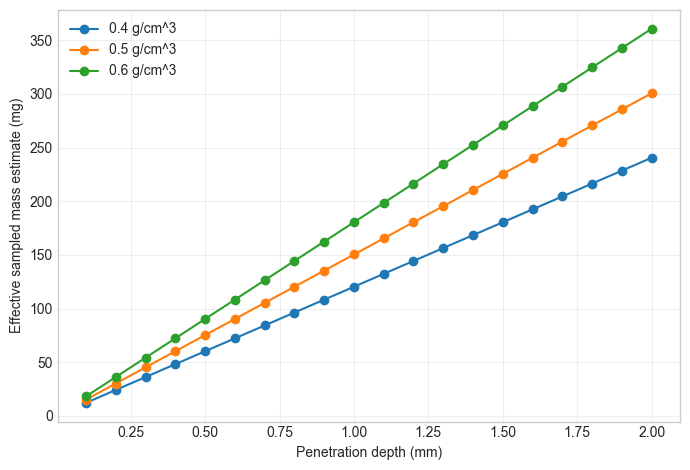

In [9]:
plot1_df = results_df[results_df['rpm'] == plot1_rpm]

fig_setup_c_plot_01, ax = plt.subplots(figsize=(7, 4.8))
for density in density_values_g_cm3:
    series_df = plot1_df[plot1_df['density_g_cm3'] == density]
    ax.plot(
        series_df['penetration_depth_mm'],
        series_df['effective_sampled_mass_estimate_mg'],
        marker='o',
        label=f'{density:.1f} g/cm^3',
    )
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Effective sampled mass estimate (mg)')
ax.grid(True, alpha=0.3)
ax.legend()
fig_setup_c_plot_01.tight_layout()
plt.show()

In [10]:
display(Markdown(
    f"## Effective Sampled Mass Estimate vs RPM\n\n"
    f"This plot shows the effective sampled mass estimate as a function of wheel speed at a "
    f"penetration depth of {plot2_penetration_depth_mm} mm and an acquisition time of "
    f"{acquisition_time_s} s. Each curve represents one bulk density.\n\n"
    f"The overall trend is upward: faster rotation moves powder past the probe more quickly, "
    f"increasing the number of renewal events and therefore the accumulated sampled mass.\n\n"
    f"The visible jigsaw or sawtooth pattern is caused by the ceiling function used to count "
    f"finger passes. At certain RPM values a new finger pass is added, which causes blocked time "
    f"to jump up and effective observation time to drop. The estimate therefore dips briefly before "
    f"the continued increase in renewal rate compensates. This creates the characteristic "
    f"staircase-like zigzag rather than a smooth curve.\n\n"
    f"Higher density shifts the entire curve upward without changing the shape, because density "
    f"scales the per-refresh sampled mass but does not affect blocking or renewal count.\n\n"
    f"Shortening the acquisition time would compress the curve downward — fewer renewals fit into "
    f"a shorter window. Lengthening it would raise the curve, but with diminishing returns as "
    f"cumulative finger-blocking grows."
))

## Effective Sampled Mass Estimate vs RPM

This plot shows the effective sampled mass estimate as a function of wheel speed at a penetration depth of 1.0 mm and an acquisition time of 1.8 s. Each curve represents one bulk density.

The overall trend is upward: faster rotation moves powder past the probe more quickly, increasing the number of renewal events and therefore the accumulated sampled mass.

The visible jigsaw or sawtooth pattern is caused by the ceiling function used to count finger passes. At certain RPM values a new finger pass is added, which causes blocked time to jump up and effective observation time to drop. The estimate therefore dips briefly before the continued increase in renewal rate compensates. This creates the characteristic staircase-like zigzag rather than a smooth curve.

Higher density shifts the entire curve upward without changing the shape, because density scales the per-refresh sampled mass but does not affect blocking or renewal count.

Shortening the acquisition time would compress the curve downward — fewer renewals fit into a shorter window. Lengthening it would raise the curve, but with diminishing returns as cumulative finger-blocking grows.

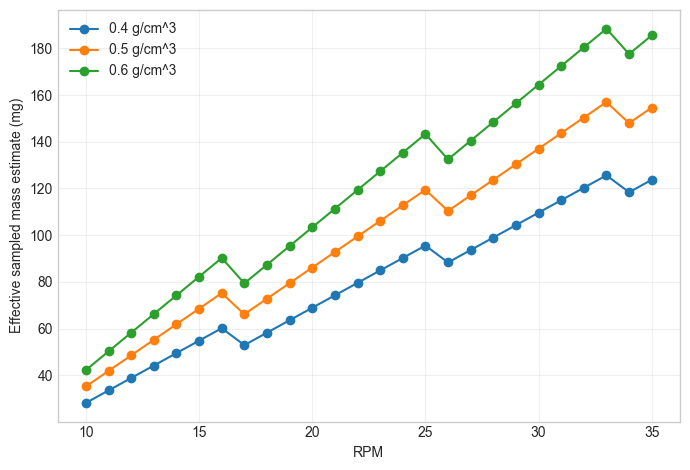

In [11]:
plot2_df = results_df[np.isclose(results_df['penetration_depth_mm'], plot2_penetration_depth_mm)]

fig_setup_c_plot_02, ax = plt.subplots(figsize=(7, 4.8))
for density in density_values_g_cm3:
    series_df = plot2_df[plot2_df['density_g_cm3'] == density]
    ax.plot(
        series_df['rpm'],
        series_df['effective_sampled_mass_estimate_mg'],
        marker='o',
        label=f'{density:.1f} g/cm^3',
    )
ax.set_xlabel('RPM')
ax.set_ylabel('Effective sampled mass estimate (mg)')
ax.grid(True, alpha=0.3)
ax.legend()
fig_setup_c_plot_02.tight_layout()
plt.show()

In [12]:
display(Markdown(
    f"## Heatmap of Effective Sampled Mass Estimate\n\n"
    f"This heatmap presents the coupled effect of RPM and penetration depth at a representative "
    f"bulk density of {plot3_density_g_cm3} g/cm³. It is useful for identifying broad operating "
    f"regions rather than a single one-dimensional trend.\n\n"
    f"Because both deterministic renewal count and sampled mass per refresh event contribute to "
    f"the final estimate, the heatmap makes it easier to see where different RPM-depth combinations "
    f"produce similar effective sampled mass estimate values."
))

## Heatmap of Effective Sampled Mass Estimate

This heatmap presents the coupled effect of RPM and penetration depth at a representative bulk density of 0.4 g/cm³. It is useful for identifying broad operating regions rather than a single one-dimensional trend.

Because both deterministic renewal count and sampled mass per refresh event contribute to the final estimate, the heatmap makes it easier to see where different RPM-depth combinations produce similar effective sampled mass estimate values.

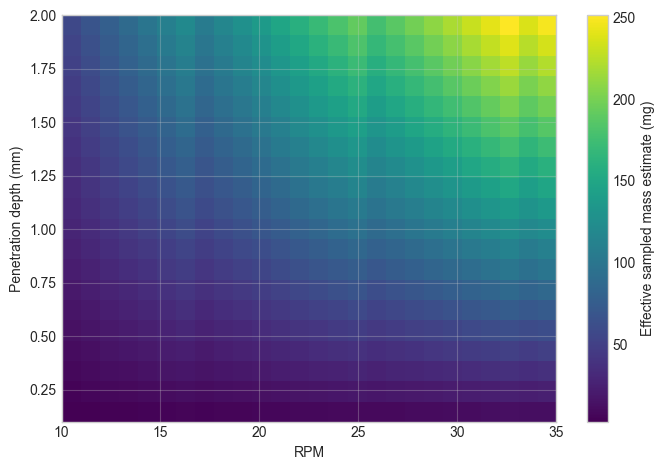

In [13]:
fig_setup_c_plot_03, ax = plt.subplots(figsize=(7, 4.8))
im1 = ax.imshow(
    heatmap_05_df.values,
    aspect='auto',
    origin='lower',
    extent=[
        heatmap_05_df.columns.min(),
        heatmap_05_df.columns.max(),
        heatmap_05_df.index.min(),
        heatmap_05_df.index.max(),
    ],
    cmap='viridis',
)
ax.set_xlabel('RPM')
ax.set_ylabel('Penetration depth (mm)')
ax.grid(True, alpha=0.3)
fig_setup_c_plot_03.colorbar(im1, ax=ax, label='Effective sampled mass estimate (mg)')
fig_setup_c_plot_03.tight_layout()
plt.show()

## Blocked Time Fraction vs RPM

This plot separates the blocking model from the sampled-mass model. It shows how much of the acquisition is estimated to be unavailable because the spiderwheel fingers overlap the probe region under the binary blocking approximation.

The blocked fraction matters because it reduces effective observation time even in cases where wheel speed increases the rate of renewal opportunities.

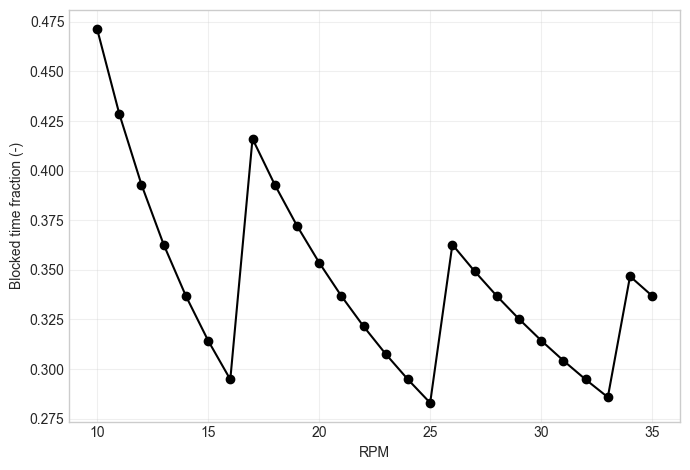

In [14]:
fig_setup_c_plot_04, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(
    blocking_summary_df['rpm'],
    blocking_summary_df['blocked_time_s'] / acquisition_time_s,
    marker='o',
    color='black',
)
ax.set_xlabel('RPM')
ax.set_ylabel('Blocked time fraction (-)')
ax.grid(True, alpha=0.3)
fig_setup_c_plot_04.tight_layout()
plt.show()

## Sampled Mass per Refresh vs Penetration Depth

This plot shows the sampled mass per refresh event before the renewal-count multiplier is applied. It therefore isolates the sampled-volume approximation from the dynamic renewal approximation.

Reading this plot together with the penetration-depth plot above helps distinguish two quantities that should not be conflated: $m_{\mathrm{sample}}$ is the per-refresh sampled mass, whereas $m_{\mathrm{eff,est}}$ is the effective sampled mass estimate accumulated over one acquisition.

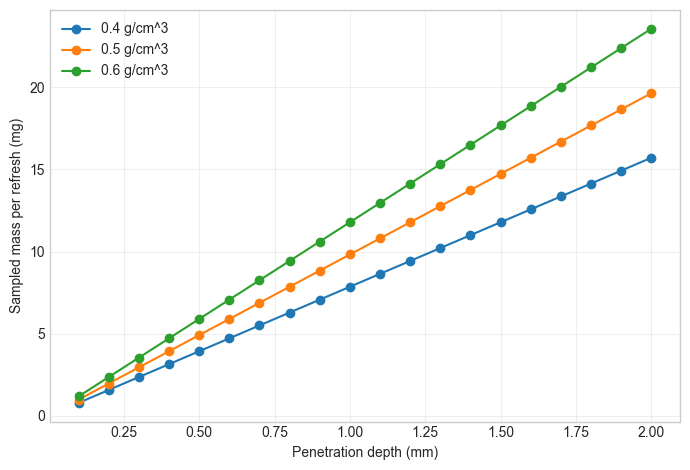

In [15]:
fig_setup_c_plot_05, ax = plt.subplots(figsize=(7, 4.8))
for density in density_values_g_cm3:
    series_df = plot1_df[plot1_df['density_g_cm3'] == density]
    ax.plot(
        series_df['penetration_depth_mm'],
        series_df['sampled_mass_per_refresh_mg'],
        marker='o',
        label=f'{density:.1f} g/cm^3',
    )
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Sampled mass per refresh (mg)')
ax.grid(True, alpha=0.3)
ax.legend()
fig_setup_c_plot_05.tight_layout()
plt.show()

In [16]:
display(Markdown(
    f"## Contour Map of Effective Sampled Mass Estimate\n\n"
    f"This contour plot provides the same coupled RPM-depth view as the heatmap, but for the "
    f"higher-density case of {plot6_density_g_cm3} g/cm³. It is useful for visualizing smooth "
    f"operating envelopes and approximate iso-mass contours.\n\n"
    f"The figure remains a first-order mechanistic map. It is useful for design sensitivity "
    f"screening, but it should not be interpreted as a validated surface of statistically "
    f"independent effective sample size."
))

## Contour Map of Effective Sampled Mass Estimate

This contour plot provides the same coupled RPM-depth view as the heatmap, but for the higher-density case of 0.4 g/cm³. It is useful for visualizing smooth operating envelopes and approximate iso-mass contours.

The figure remains a first-order mechanistic map. It is useful for design sensitivity screening, but it should not be interpreted as a validated surface of statistically independent effective sample size.

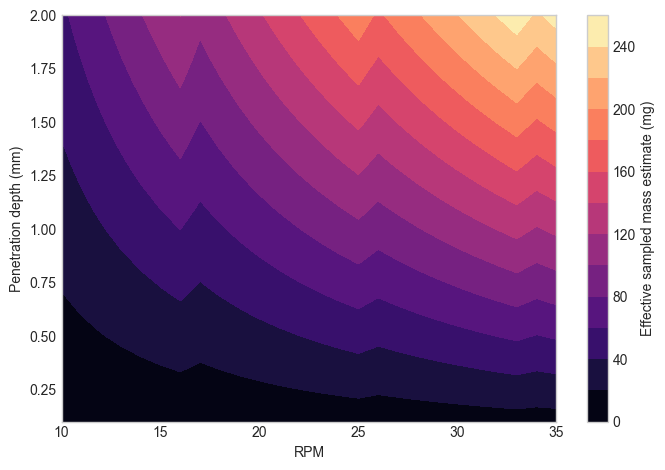

In [17]:
rpm_grid, depth_grid = np.meshgrid(heatmap_06_df.columns.values, heatmap_06_df.index.values)

fig_setup_c_plot_06, ax = plt.subplots(figsize=(7, 4.8))
im2 = ax.contourf(rpm_grid, depth_grid, heatmap_06_df.values, levels=12, cmap='magma')
ax.set_xlabel('RPM')
ax.set_ylabel('Penetration depth (mm)')
ax.grid(True, alpha=0.3)
fig_setup_c_plot_06.colorbar(im2, ax=ax, label='Effective sampled mass estimate (mg)')
fig_setup_c_plot_06.tight_layout()
plt.show()

## Results Interpretation

- increasing bulk density increases the sampled mass per refresh event linearly in this simplified volume model and therefore increases the effective sampled mass estimate proportionally when the renewal count is unchanged
- increasing penetration depth increases the assumed sampled volume linearly and therefore increases the per-refresh sampled mass linearly under the current approximation
- increasing RPM decreases the characteristic crossing time and therefore increases the deterministic number of renewal opportunities, all else being equal
- blocking reduces effective observation time and therefore reduces the effective sampled mass estimate relative to an unblocked case
- these outputs are mechanistically useful for engineering comparison, but they do not by themselves establish statistical independence of refresh events or a validated independent effective sample size

## Limitations

- partial blocking, partial transmission, and partial attenuation are not modeled; blocking is treated as binary
- recirculation, revisit probability, and repeated presentation of the same powder increment are not modeled
- particle-scale heterogeneity, segregation, and particle-count statistics are outside the present approximation
- depth-dependent photon weighting is not represented; the sampling region is treated with a uniform first-order volume approximation
- residence-time distributions and local mixing memory near the probe are not modeled
- stochastic independence of refresh events is not modeled, so renewal count is not equivalent to validated independent sample count
- the model does not yet convert effective sampled mass estimate into analytical variance, prediction uncertainty, or a validated statistical effective sample size

## Next Logical Extensions

- replace binary blocking with a partial-blocking or partial-exposure model
- include revisit probability or explicit recirculation of powder around the wheel
- resolve the acquisition in time or phase so that exposure depends on wheel angle during the spectrum
- introduce depth-dependent weighting instead of a uniform cylindrical volume approximation
- estimate particle count as well as mass within the refreshed sampling region
- apply a correlation correction between refresh events before interpreting the result as effective sample mass
- link effective sampled mass estimate to analytical variance or prediction precision

## Export and Reporting

This export section writes timestamped CSV, PNG, JSON, and Word outputs into the setup-specific `reports/` folder. `python-docx` and `nbformat` are required for Word export with Markdown rendering.

In [18]:
from pathlib import Path
import importlib
import sys

# Resolve project root dynamically (notebooks live in <project>/notebooks/)
notebook_file = globals().get("__vsc_ipynb_file__")
if notebook_file:
    project_root = Path(notebook_file).resolve().parent.parent
else:
    project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_structured_word_report = reporting_utils.build_structured_word_report
create_run_directory = reporting_utils.create_run_directory
dataframe_to_markdown_table = reporting_utils.dataframe_to_markdown_table
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json

setup_name = "setup_c"
notebook_filename = "setup_C_spiderwheel_effective_sample_size.ipynb"
notebook_path = project_root / "notebooks" / notebook_filename
report_filename = "setup_c_report.docx"

timestamp, run_dir = create_run_directory(project_root, setup_name)

summary_table_df = selected_summary_df.copy()
blocking_summary_export_df = (
    results_df[["rpm", "blocked_time_s", "effective_time_s", "n_refresh"]]
    .drop_duplicates()
    .sort_values("rpm")
    .reset_index(drop=True)
)

dataframes_to_save = {
    "results_full": results_df,
    "summary_table": summary_table_df,
    "blocking_summary": blocking_summary_export_df,
    "worked_example": worked_example_df,
}
figures_to_save = {
    "plot_01_estimate_vs_penetration_depth": globals().get("fig_setup_c_plot_01"),
    "plot_02_estimate_vs_rpm": globals().get("fig_setup_c_plot_02"),
    "plot_03_heatmap_density_05": globals().get("fig_setup_c_plot_03"),
    "plot_04_blocked_time_fraction_vs_rpm": globals().get("fig_setup_c_plot_04"),
    "plot_05_sampled_mass_per_refresh": globals().get("fig_setup_c_plot_05"),
    "plot_06_contour_density_06": globals().get("fig_setup_c_plot_06"),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    "Finger count": int(n_fingers),
    "Wheel radius (cm)": wheel_radius_cm,
    "Probe radial position (cm)": probe_radial_position_cm,
    "Finger width (cm)": finger_width_cm,
    "Probe diameter (mm)": probe_diameter_mm,
    "Acquisition time (s)": acquisition_time_s,
    "Density scenarios (g/cm^3)": [float(x) for x in density_values_g_cm3],
    "RPM range": f"{min(rpm_values)} to {max(rpm_values)}",
    "Penetration depth range (mm)": f"{penetration_depth_values_mm.min():.1f} to {penetration_depth_values_mm.max():.1f}",
}

metadata = {
    "setup_name": setup_name,
    "timestamp": timestamp,
    "notebook_filename": notebook_filename,
    "report_filename": report_filename,
    "report_layout": "structured_scientific_report",
    "csv_files": csv_files,
    "png_files": png_files,
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

executive_summary_text = (
    "Setup C treats spiderwheel presentation as a deterministic renewal problem modified by wheel-finger blocking. The report separates sampled mass per refresh event from blocked observation time and deterministic renewal count, then combines them into a first-order effective sampled-mass estimate. The main result is that penetration depth and density scale the per-refresh mass, while RPM changes both renewal rate and blocked-time behavior."
)

worked_example_report_df = worked_example_df.copy()
worked_example_report_df["value"] = worked_example_report_df["value"].map(
    lambda value: f"{value:.4f}" if isinstance(value, (int, float, np.floating)) else value
)
worked_example_body = (
    "The worked example below makes the deterministic bookkeeping explicit: per-refresh sampled mass, blocked time, effective observation time, renewal count, and the final effective sampled-mass estimate are reported separately.\n\n"
    + dataframe_to_markdown_table(worked_example_report_df)
)

parameter_sweep_body = (
    "The spiderwheel simulation sweeps density, wheel speed, and penetration depth while holding the geometry fixed. This separates three mechanisms: sampled mass per refresh event, deterministic availability of the probe due to finger blocking, and the renewal count during the unblocked acquisition window.\n\n"
    f"- densities of {', '.join(f'{density:.1f}' for density in density_values_g_cm3)} g/cm^3\n"
    f"- wheel RPM from {min(rpm_values)} to {max(rpm_values)}\n"
    f"- penetration depth from {penetration_depth_values_mm.min():.1f} to {penetration_depth_values_mm.max():.1f} mm\n\n"
    f"This produces {len(results_df)} modeled scenarios."
)

selected_results_report_df = simulation_summary_display_df.copy()
for column in [
    "density_g_cm3",
    "penetration_depth_mm",
    "blocked_time_s",
    "n_refresh",
    "sampled_mass_per_refresh_mg",
    "effective_sampled_mass_estimate_mg",
] :
    selected_results_report_df[column] = selected_results_report_df[column].map(lambda value: f"{value:.4f}" if isinstance(value, (int, float, np.floating)) else value)

blocking_highlight_df = blocking_summary_export_df[blocking_summary_export_df["rpm"].isin([10, 20, 35])].copy()
for column in ["blocked_time_s", "effective_time_s", "n_refresh"]:
    blocking_highlight_df[column] = blocking_highlight_df[column].map(lambda value: f"{value:.4f}")

selected_results_body = (
    "The first table highlights representative density-RPM-depth combinations. The second table isolates the blocking side of the model at representative wheel speeds so the reader can separate probe availability from sampled-mass-per-refresh effects.\n\n"
    + dataframe_to_markdown_table(selected_results_report_df)
    + "\n\nRepresentative blocking summary\n\n"
    + dataframe_to_markdown_table(blocking_highlight_df)
)

figure_section_body = (
    "The figures are ordered from mechanism to response: sampled mass per refresh and blocked-time fraction first, then the accumulated effective sampled-mass estimate as one-dimensional and two-dimensional response maps."
)
figure_entries = [
    {
        "filename": "plot_05_sampled_mass_per_refresh.png",
        "caption": "Figure 1. Sampled mass per refresh versus penetration depth, isolating the optical-volume approximation from the renewal multiplier.",
    },
    {
        "filename": "plot_04_blocked_time_fraction_vs_rpm.png",
        "caption": "Figure 2. Blocked-time fraction versus wheel RPM, isolating the binary blocking model.",
    },
    {
        "filename": "plot_01_estimate_vs_penetration_depth.png",
        "caption": "Figure 3. Effective sampled-mass estimate versus penetration depth at representative wheel speed.",
    },
    {
        "filename": "plot_02_estimate_vs_rpm.png",
        "caption": "Figure 4. Effective sampled-mass estimate versus wheel RPM at representative penetration depth.",
    },
    {
        "filename": "plot_03_heatmap_density_05.png",
        "caption": "Figure 5. Heatmap of the effective sampled-mass estimate over RPM and penetration depth for the representative 0.5 g/cm^3 density case.",
    },
    {
        "filename": "plot_06_contour_density_06.png",
        "caption": "Figure 6. Contour map of the effective sampled-mass estimate over RPM and penetration depth for the 0.6 g/cm^3 density case.",
    },
]

report_sections = [
    {"source": "notebook", "heading": "## Background"},
    {"source": "notebook", "heading": "## Objective"},
    {"source": "notebook", "heading": "## Theory"},
    {"source": "notebook", "heading": "## Interpretation of the Model"},
    {"source": "notebook", "heading": "## Assumptions"},
    {"source": "notebook", "heading": "## Single-Case Worked Example"},
    {"source": "content", "heading": "Worked example summary", "body": worked_example_body},
    {"source": "notebook", "heading": "## Parameter Sweep / Simulation"},
    {"source": "content", "heading": "Selected results table", "body": selected_results_body},
    {"source": "content", "heading": "Figures", "body": figure_section_body, "figures": figure_entries},
    {"source": "notebook", "heading": "## Results Interpretation"},
    {"source": "notebook", "heading": "## Limitations"},
]
appendix_sections = [
    {"source": "notebook", "heading": "## Next Logical Extensions"},
]

build_structured_word_report(
    report_title="Setup C Spiderwheel Effective Sample Size Report",
    setup_name=setup_name,
    timestamp=timestamp,
    run_dir=run_dir,
    notebook_path=notebook_path,
    output_filename=report_filename,
    executive_summary_text=executive_summary_text,
    parameter_summary=parameter_summary,
    report_sections=report_sections,
    appendix_sections=appendix_sections,
    csv_filenames=csv_files,
    figure_filenames=png_files,
)

print(f"Report run directory: {run_dir}")

Report run directory: C:\temp files\EFS\reports\setup_c\20260417_150638
